In [1]:
# Load FOLDOC.txt into variable 'corpus'
from pathlib import Path
corpus_path = Path("FOLDOC.txt")
# Try current notebook directory if not found
if not corpus_path.exists():
    corpus_path = Path.cwd() / "FOLDOC.txt"
with corpus_path.open("r", encoding="utf-8") as f:
    corpus = f.read()

# Basic check
print(f"Loaded corpus: {len(corpus)} characters")

Loaded corpus: 5452376 characters


In [2]:
from transformers import BertTokenizer


tokenizer = BertTokenizer.from_pretrained("google-bert/bert-base-uncased")
tokens = tokenizer.tokenize(corpus)
print(len(tokens))


c:\Users\brtoone\python\llm\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1386590


In [3]:
# Convert `tokens` (list) to sequential IDs: token -> 0,1,2,...
# Place this cell after the tokenizer cell. Creates `token_to_id` and `id_to_token`.
try:
    tokens
except NameError:
    raise NameError("`tokens` not found. Run the tokenizer cell first.")

# Preserve first-occurrence order and assign sequential IDs
unique_tokens = list(dict.fromkeys(tokens))
token_to_id = {tok: i for i, tok in enumerate(unique_tokens)}
id_to_token = {i: tok for tok, i in token_to_id.items()}

print(f"Assigned {len(token_to_id)} token IDs")
print("First 20 token->id entries:")
for tok, idx in list(token_to_id.items())[:20]:
    print(f"{tok!r}: {idx}")

# Keep variables in the notebook namespace for later use


Assigned 17899 token IDs
First 20 token->id entries:
'helicopter': 0
'free': 1
'on': 2
'-': 3
'line': 4
'dictionary': 5
'of': 6
'computing': 7
'<': 8
'introduction': 9
'>': 10
'fold': 11
'##oc': 12
'is': 13
'a': 14
'search': 15
'##able': 16
'acronym': 17
'##s': 18
',': 19


In [4]:
import torch
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

# Ensure `token_to_id` is available
try:
    tokens
    token_to_id    
except NameError:
    raise NameError("`token_to_id` not found. Run the previous cells that load the corpus and initialize the tokenizer.")

inputs_list = []
labels_list = []
current_input = []
current_label = []

for t in tokens:
    if t==".":
        inputs_list.append(torch.tensor(current_input))
        labels_list.append(torch.tensor(current_label[1:]+[token_to_id["."]]))
        current_input = []
        current_label = []
    else:
        current_input.append(token_to_id[t])
        current_label.append(token_to_id[t])

print(len(inputs_list))
print(len(inputs_list[0]))
print(len(inputs_list[1]))
print(labels_list[0])
print(len(labels_list))
inputs = torch.tensor(pad_sequence(inputs_list, False, 17898 ))
labels = torch.tensor(pad_sequence(labels_list, False, 17898 ))

dataset = TensorDataset(inputs, labels)
dataloader = DataLoader(dataset)

67624
67
30
tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,  5,  6,
        17, 18, 19, 20, 21, 19, 22, 23, 19, 24, 19, 25, 19, 26, 27, 19, 28, 19,
        29, 19, 30, 19, 31, 19, 32, 19, 33, 18, 19, 34, 19, 35, 19, 36, 19, 37,
        19, 38, 19, 39, 19, 40, 41, 42, 43, 44, 45,  7, 46])
67624


C:\Users\brtoone\AppData\Local\Temp\ipykernel_4584\3025805850.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  inputs = torch.tensor(pad_sequence(inputs_list, False, 17898 ))
C:\Users\brtoone\AppData\Local\Temp\ipykernel_4584\3025805850.py:34: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels = torch.tensor(pad_sequence(labels_list, False, 17898 ))


In [5]:
import torch.nn as nn

class PositionEncoding(nn.Module):
    
    def __init__(self, d_model=512, max_len=200):
        ## d_model = The dimension of the transformer, which is also the number of embedding values per token.
        ##           In the transformer I used in the StatQuest: Transformer Neural Networks Clearly Explained!!!
        ##           d_model=2, so that's what we'll use as a default for now.
        ##           However, in "Attention Is All You Need" d_model=512
        ## max_len = maximum number of tokens we allow as input.
        ##           Since we are precomputing the position encoding values and storing them in a lookup table
        ##           we can use d_model and max_len to determine the number of rows and columns in that
        ##           lookup table.
        ##
        ##           In this simple example, we are only using short phrases, so we are using
        ##           max_len=6 as the default setting.
        ##           However, in The Annotated Transformer, they set the default value for max_len to 5000
        
        super().__init__()
        ## We call the super's init because by creating our own __init__() method, we overwrite the one
        ## we inherited from nn.Module. So we have to explicity call nn.Module's __init__(), otherwise it
        ## won't get initialized. NOTE: If we didn't write our own __init__(), then we would not have
        ## to call super().__init__(). Alternatively, if we didn't want to access any of nn.Module's methods, 
        ## we wouldn't have to call it then either.

        ## Now we create a lookup table, pe, of position encoding values and initialize all of them to 0.
        ## To do this, we will make a matrix of 0s that has max_len rows and d_model columns.
        ## for example...
        ## torch.zeros(3, 2)
        ## ...returns a matrix of 0s with 3 rows and 2 columns...
        ## tensor([[0., 0.],
        ##         [0., 0.],
        ##         [0., 0.]])
        pe = torch.zeros(max_len, d_model)

        ## Now we create a sequence of numbers for each position that a token can have in the input (or output).
        ## For example, if the input tokens where "I'm happy today!", then "I'm" would get the first
        ## position, 0, "happy" would get the second position, 1, and "today!" would get the third position, 2.
        ## NOTE: Since we are going to be doing math with these position indices to create the 
        ## positional encoding for each one, we need them to be floats rather than ints.
        ## 
        ## NOTE: Two ways to create floats are...
        ##
        ## torch.arange(start=0, end=3, step=1, dtype=torch.float)
        ##
        ## ...and...
        ##
        ## torch.arange(start=0, end=3, step=1).float()
        ##
        ## ...but the latter is just as clear and requires less typing.
        ##
        ## Lastly, .unsqueeze(1) converts the single list of numbers that torch.arange creates into a matrix with
        ## one row for each index, and all of the indices in a single column. So if "max_len" = 3, then we
        ## would create a matrix with 3 rows and 1 column like this...
        ##
        ## torch.arange(start=0, end=3, step=1, dtype=torch.float).unsqueeze(1)
        ##
        ## ...returns...
        ##
        ## tensor([[0.],
        ##         [1.],
        ##         [2.]])        
        position = torch.arange(start=0, end=max_len, step=1).float().unsqueeze(1)


        ## Here is where we start doing the math to determine the y-axis coordinates on the
        ## sine and cosine curves.
        ##
        ## The positional encoding equations used in "Attention is all you need" are...
        ##
        ## PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
        ## PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
        ##
        ## ...and we see, within the sin() and cos() functions, we divide "pos" by some number that depends
        ## on the index (i) and total number of PE values we want per token (d_model). 
        ##
        ## NOTE: When the index, i, is 0 then we are calculating the y-axis coordinates on the **first pair** 
        ##       of sine and cosine curves. When i=1, then we are calculating the y-axis coordiantes on the 
        ##       **second pair** of sine and cosine curves. etc. etc.
        ##
        ## Now, pretty much everyone calculates the term we use to divide "pos" by first, and they do it with
        ## code that looks like this...
        ##
        ## div_term = torch.exp(torch.arange(start=0, end=d_model, step=2).float() * -(math.log(10000.0) / d_model))
        ##
        ## Now, at least to me, it's not obvious that div_term = 1/(10000^(2i/d_model)) for a few reasons:
        ##
        ##    1) div_term wraps everything in a call to torch.exp() 
        ##    2) It uses log()
        ##    2) The order of the terms is different 
        ##
        ## The reason for these differences is, presumably, trying to prevent underflow (getting too close to 0).
        ## So, to show that div_term = 1/(10000^(2i/d_model))...
        ##
        ## 1) Swap out math.log() for torch.log() (doing this requires converting 10000.0 to a tensor, which is my
        ##    guess for why they used math.log() instead of torch.log())...
        ##
        ## torch.exp(torch.arange(start=0, end=d_model, step=2).float() * -(torch.log(torch.tensor(10000.0)) / d_model))
        ##
        ## 2) Rearrange the terms...
        ##
        ## torch.exp(-1 * (torch.log(torch.tensor(10000.0)) * torch.arange(start=0, end=d_model, step=2).float() / d_model))
        ##
        ## 3) Pull out the -1 with exp(-1 * x) = 1/exp(x)
        ##
        ## 1/torch.exp(torch.log(torch.tensor(10000.0)) * torch.arange(start=0, end=d_model, step=2).float() / d_model)
        ##
        ## 4) Use exp(a * b) = exp(a)^b to pull out the 2i/d_model term...
        ##
        ## 1/torch.exp(torch.log(torch.tensor(10000.0)))^(torch.arange(start=0, end=d_model, step=2).float() / d_model)
        ##
        ## 5) Use exp(log(x)) = x to get the original form of the denominator...
        ##
        ## 1/(torch.tensor(10000.0)^(torch.arange(start=0, end=d_model, step=2).float() / d_model))
        ##
        ## 6) Bam.
        ## 
        ## So, that being said, I don't think underflow is actually that big an issue. In fact, some coder at Hugging Face
        ## also doesn't think so, and their code for positional encoding in DistilBERT (a streamlined version of BERT, which
        ## is a transformer model)
        ## calculates the values directly - using the form of the equation found in original Attention is all you need
        ## manuscript. See...
        ## https://github.com/huggingface/transformers/blob/455c6390938a5c737fa63e78396cedae41e4e87e/src/transformers/modeling_distilbert.py#L53
        ## So I think we can simplify the code, but I'm also writing all these comments to show that it is equivalent to what
        ## you'll see in the wild...
        ##
        ## Now let's create an index for the embedding positions to simplify the code a little more...
        embedding_index = torch.arange(start=0, end=d_model, step=2).float()
        ## NOTE: Setting step=2 results in the same sequence numbers that we would get if we multiplied i by 2.
        ##       So we can save ourselves a little math by just setting step=2.

        ## And now, finally, let's create div_term...
        div_term = 1/torch.tensor(10000.0)**(embedding_index / d_model)
        
        ## Now we calculate the actual positional encoding values. Remember 'pe' was initialized as a matrix of 0s
        ## with max_len (max number of input tokens) rows and d_model (number of embedding values per token) columns.
        pe[:, 0::2] = torch.sin(position * div_term) ## every other column, starting with the 1st, has sin() values
        pe[:, 1::2] = torch.cos(position * div_term) ## every other column, starting with the 2nd, has cos() values
        ## NOTE: If the notation for indexing 'pe[]' looks cryptic to you, read on...
        ##
        ## First, let's look at the general indexing notation:
        ##
        ## For each row or column in matrix we can select elements in that
        ## row or column with the following indexs...
        ##
        ## i:j:k = select elements between i and j with stepsize = k.
        ##
        ## ...where...
        ##
        ## i defaults to 0
        ## j defaults to the number of elements in the row, column or whatever.
        ## k defaults to 1
        ##
        ## Now that we have looked at the general notation, let's look at specific
        ## examples so that we can understand it.
        ##
        ## We'll start with: pe[:, 0::2]
        ##
        ## The stuff that comes before the comma (in this case ':') refers to the rows we want to select.
        ## The ':' before the comma means "select all rows" because we are not providing specific 
        ## values for i, j and k and, instead, just using the default values.
        ##
        ## The stuff after the comma refers to the columns we want to select.
        ## In this case, we have '0::2', and that means we start with
        ## the first column (column =  0) and go to the end (using the default value for j)
        ## and we set the stepsize to 2, which means we skip every other column.
        ##
        ## Now to understand pe[:, 1::2]
        ##
        ## Again, the stuff before the comma refers to the rows, and, just like before
        ## we use default values for i,j and k, so we select all rows.
        ##
        ## The stuff that comes after the comma refers to the columns.
        ## In this case, we start with the 2nd column (column = 1), and go to the end
        ## (using the default value for 'j') and we set the stepsize to 2, which
        ## means we skip every other column.
        ##
        ## NOTE: using this ':' based notation is called "indexing" and also called "slicing"
        
        ## Now we "register 'pe'.
        self.register_buffer('pe', pe) ## "register_buffer()" ensures that
                                       ## 'pe' will be moved to wherever the model gets
                                       ## moved to. So if the model is moved to a GPU, then,
                                       ## even though we don't need to optimize 'pe', it will 
                                       ## also be moved to that GPU. This, in turn, means
                                       ## that accessing 'pe' will be relatively fast copared
                                       ## to having a GPU have to get the data from a CPU.

    ## Because this class, PositionEncoding, inherits from nn.Module, the forward() method 
    ## is called by default when we use a PositionEncoding() object.
    ## In other words, after we create a PositionEncoding() object, pe = PositionEncoding(),
    ## then pe(word_embeddings) will call forward() and so this is where 
    ## we will add the position encoding values to the word embedding values
    def forward(self, word_embeddings):
        return word_embeddings + self.pe[:word_embeddings.size(0), :] ## word_embeddings.size(0) = number of embeddings
                                                                      ## NOTE: That second ':' is optional and 
                                                                      ## we could re-write it like this: 
                                                                      ## self.pe[:word_embeddings.size(0)]

In [9]:
print(token_to_id["helicopter"])
print(token_to_id["jet"])
print(token_to_id["pizza"])
print(token_to_id["airplane"])
print(token_to_id["plane"])


0
8461
15896
4672
5380


In [32]:
import gensim.downloader
glove_vectors = gensim.downloader.load('glove-wiki-gigaword-50')


In [35]:
import torch.nn as nn
import numpy as np
import torch.nn

num_tokens = len(token_to_id)

# set freeze to false if you want them to be trainable
weights = torch.FloatTensor(glove_vectors.vectors)    
we = torch.nn.Embedding.from_pretrained(weights,freeze=True) 
#we = nn.Embedding(num_embeddings=num_tokens,embedding_dim=512)     
pe = PositionEncoding(d_model=50,max_len=200)


16.121752
17.498747
22.103756
31.624136
tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,  5,
         6, 17, 18, 19, 20, 21, 19, 22, 23, 19, 24, 19, 25, 19, 26, 27, 19, 28,
        19, 29, 19, 30, 19, 31, 19, 32, 19, 33, 18, 19, 34, 19, 35, 19, 36, 19,
        37, 19, 38, 19, 39, 19, 40, 41, 42, 43, 44, 45,  7])
tensor([47, 48, 49, 50, 51, 52, 13, 53, 43, 54, 19, 55, 56, 57, 58, 59, 60, 61,
        62, 63, 64,  6, 63, 65,  1, 66, 67, 19, 68, 69])


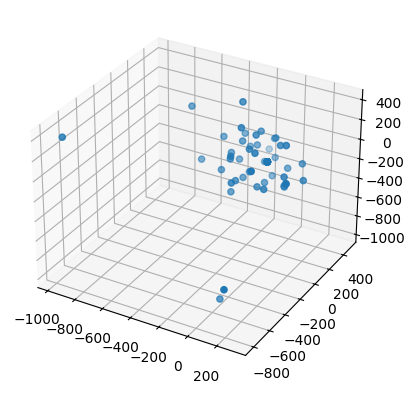

In [44]:
import torch.nn as nn
import numpy as np

sample_input0 = inputs_list[0]
word_embeddings0 = we(sample_input0)        
position_encoded0 = pe(word_embeddings0)
# let's compare the word embeddings for airplane, jet, helicopter, and pizza
input_str = "airplane jet plane helicopter tuning airplane"
word_embeddings = [glove_vectors[w] for w in input_str.split()]
#position_encodings_for_input_str = pe(word_embeddings_for_input_str)
#print(word_embeddings_for_input_str)
#print(position_encodings_for_input_str)

# calculate the similarity between each word embedding
we_as_a_list = word_embeddings
we_airplane = np.array(we_as_a_list[0])
we_jet = np.array(we_as_a_list[1])
we_plane = np.array(we_as_a_list[2])
we_helicopter = np.array(we_as_a_list[3])
we_pizza = np.array(we_as_a_list[4])
diff = np.sum(np.absolute(we_airplane-we_jet))
diff2 = np.sum(np.absolute(we_airplane-we_plane))
diff3 = np.sum(np.absolute(we_airplane-we_helicopter))
diff4 = np.sum(np.absolute(we_airplane-we_pizza))
print(diff) 
print(diff2)
print(diff3)
print(diff4)

sample_input1 = inputs_list[1]

word_embeddings1 = we(sample_input1)        
position_encoded1 = pe(word_embeddings1)
print(sample_input0)
print(sample_input1)
#print(word_embeddings0[12])
#print(word_embeddings1[6])
#print(position_encoded0)
#print(position_encoded1)

from sklearn.manifold import TSNE

x_np = word_embeddings0.numpy()
x3d = TSNE(n_components=3, perplexity=30, learning_rate=200).fit_transform(x_np)

#proj = torch.nn.Linear(512, 3)
#x3d = proj(word_embeddings0).detach().numpy()
#print(len(x3d))

import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x3d[:,0], x3d[:,1], x3d[:,2])
plt.show()
